In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
using SparseArrays
using Printf

# Questão 2

In [2]:
function dif_1_avançada(f, vec_x, h)
    dif_vec = []
    for j in 1:length(vec_x)-1
        derivada = (f(vec_x[j+1]) - f(vec_x[j]))/h
        append!(dif_vec, derivada)
    end

    return dif_vec
end

dif_1_avançada (generic function with 1 method)

In [3]:
function dif_1_centrada(f, vec_x, h)
    dif_vec = []
    for j in 2:length(vec_x)-1
        derivada = (f(vec_x[j+1]) - f(vec_x[j-1]))/(2*h)
        append!(dif_vec, derivada)
    end

    return dif_vec
end

dif_1_centrada (generic function with 1 method)

In [4]:
function dif_2_centrada(f, vec_x, h)
    dif_vec = []
    for j in 2:length(vec_x)-1
        derivada = (f(vec_x[j+1]) -2*(f(vec_x[j])) + f(vec_x[j-1]))/(h^2)
        append!(dif_vec, derivada)
    end

    return dif_vec
end

dif_2_centrada (generic function with 1 method)

In [5]:
function convergencia_erro(f, derivada_analitica, aproximador, intervalo, vec_n, vec_h, desconsiderar)
    iteracoes = []
    for iter in 1:length(vec_n)
        n = vec_n[iter]
        h = vec_h[iter]
        vec_x = collect(intervalo[1]:h:intervalo[2])

        sol_exata = []
        for j in 1:n+1
            if !(j in desconsiderar[iter])
                append!(sol_exata, derivada_analitica(vec_x[j]))
            end
        end
        
        sol_approx = aproximador(f, vec_x, h)

        #display(vec_x)
        #display(sol_exata)
        #display(sol_approx)
        erros = abs.(sol_exata .- sol_approx)
        max_erro = maximum(erros)

        append!(iteracoes, [[erros, max_erro]])
    end

    return iteracoes
end

convergencia_erro (generic function with 1 method)

In [6]:
function plot_convergencia(vec_h, lista_vec_erros, plt, lista_metodos)
    plot!(plt, vec_h, vec_h,    label=L"h", ls=:dot, lw=3)
    plot!(plt, vec_h, vec_h.^2, label=L"h^2", ls=:dot, lw=3)
    
    for i in 1:length(lista_vec_erros)
        vec_erros = lista_vec_erros[i]
        plot!(  plt, 
                vec_h, 
                vec_erros, 
                label=lista_metodos[i], 
                marker=:auto, 
                lw=3, 
                xscale=:log10,
                xlabel="h",
                yscale=:log10, 
                ylabel="Erro absoluto máximo",
                #minorgrid=true,
                legend=:bottomright)
    end

    return plt
end

plot_convergencia (generic function with 1 method)

In [7]:
function run_case(vec_n, latex_function_string, interval)
    vec_h = (interval[2] - interval[1])./vec_n    
    
    desconsiderar_avançada = map(x -> [x+1], vec_n)
    iters_dif_1_avançada = convergencia_erro(f(0), f(1), dif_1_avançada, interval, vec_n, vec_h, desconsiderar_avançada)
    err_maximos_avançada = map(x -> x[2], iters_dif_1_avançada)
    
    desconsiderar_centrada = map(x -> [1, x+1], vec_n)
    iters_dif_1_centrada = convergencia_erro(f(0), f(1), dif_1_centrada, interval, vec_n, vec_h, desconsiderar_centrada)
    err_maximos_centrada = map(x -> x[2], iters_dif_1_centrada)

    iters_dif_2_centrada = convergencia_erro(f(0), f(2), dif_2_centrada, interval, vec_n, vec_h, desconsiderar_centrada)
    err_maximos_2_centrada = map(x -> x[2], iters_dif_2_centrada)

    #display(iters_dif_1_avançada)
    #display(iters_dif_1_centrada)
    metodos = ["Dif. fin. avançada", "Dif. fin. centrada", "Dif. fin. ord. 2. centrada"]
    
    plt = plot(title = "Convergência para " * latex_function_string)
    
    plt = plot_convergencia(vec_h, [err_maximos_avançada, err_maximos_centrada, err_maximos_2_centrada], plt, metodos)
    display(plt)
end

run_case (generic function with 1 method)

## *i)*

In [8]:
function f(ordem)
    if (ordem == 0)
        return x -> x * abs(x)
    end
    if (ordem == 1)
        return function(x)
                if (x != 0)
                    return (2*x^2)/abs(x)
                else
                    return 0
                end
        end
    end

    if (ordem == 2)
        return x -> (2*x)/abs(x)
    end
end

intervalo = [-1, 1];

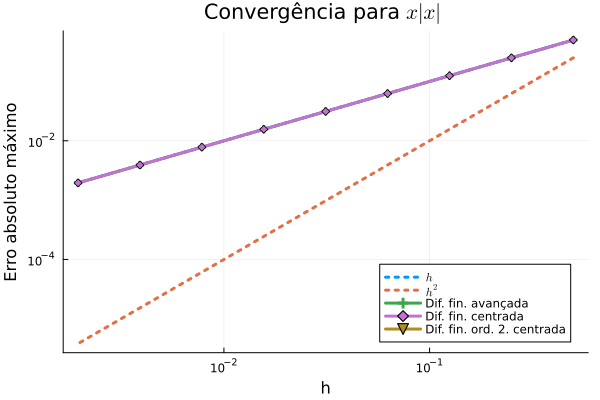

In [9]:
latex_function_string = L"$x |x|$"
vec_n = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
run_case(vec_n, latex_function_string, intervalo)

## *ii)*

In [10]:
function f(ordem)
    if (ordem == 0)
        return x -> 2 * ℯ^(cos(x)^2)
    end
    
    if (ordem == 1)
        return x -> -4 * sin(x) * (ℯ^(cos(x)^2)) * cos(x)
    end

    if (ordem == 2)
        return x -> 4 * ℯ^(cos(x)^2) * (sin(x)^2 + (2 * sin(x)^2 - 1) * cos(x)^2)
    end
end

intervalo = [0, 2 * π];

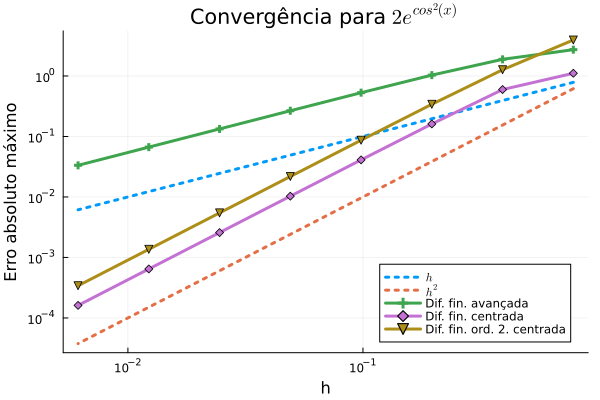

In [11]:
latex_function_string = L"$2 e^{cos^2(x)}$"
vec_n = [8, 16, 32, 64, 128, 256, 512, 1024]
run_case(vec_n, latex_function_string, intervalo)

## *iii)*

In [12]:
function f(ordem)
    if (ordem == 0)
        return x -> sin(x) * ℯ^(cos(2*x))
    end
    
    if (ordem == 1)
        return x -> ℯ^cos(2*x) * (cos(x) - 2*sin(x)*sin(2*x))
    end

    if (ordem == 2)
        return x -> -ℯ^cos(2*x) * (sin(x)*(-4*sin(2*x)^2 + 4*cos(2*x)+1) + 4*sin(2*x)*cos(x))
    end
end

intervalo = [0, 2 * π];

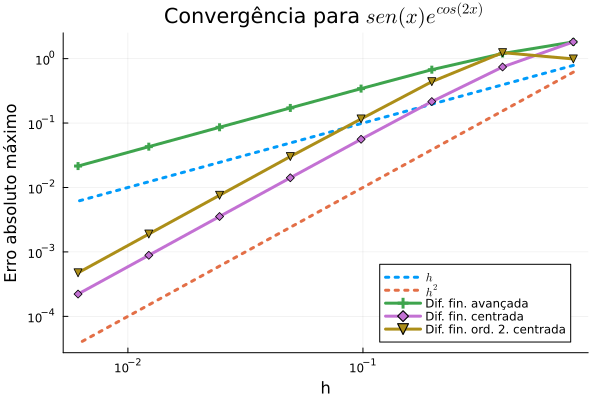

In [13]:
latex_function_string = L"$sen(x) e^{cos(2x)}$"
vec_n = [8, 16, 32, 64, 128, 256, 512, 1024]
run_case(vec_n, latex_function_string, intervalo)

## *iv)*

In [14]:
function f(ordem)
    if (ordem == 0)
        return x -> x * log(x^2 + 1)
    end
    
    if (ordem == 1)
        return x -> ((2* x^2)/(x^2 + 1)) + log(x^2 + 1)
    end

    if (ordem == 2)
        return x -> (2*x*(x^2 + 3))/(x^2 + 1)^2
    end
end

intervalo = [0, 1];

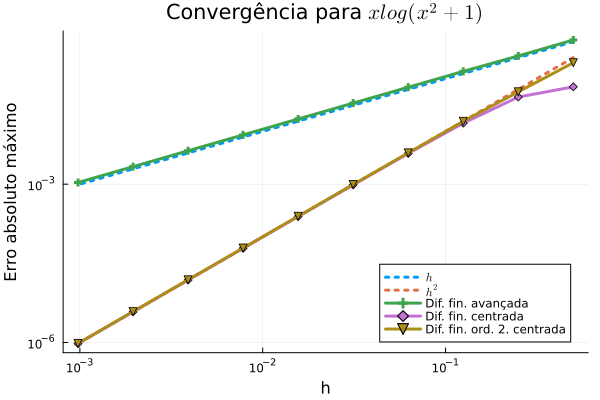

In [15]:
latex_function_string = L"$x log(x^2+1)$"
vec_n = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
run_case(vec_n, latex_function_string, intervalo)

# Questão 3

In [16]:
function resolve_dif_fin_1(vec_func, interval, coef_conds, N)
    p, q, r       = vec_func
    a, b          = interval
    α_I, β_I, γ_I = coef_conds[1]
    α_F, β_F, γ_F = coef_conds[2]
    h             = (b - a)/N
    qtd_pts = N+1
    n = qtd_pts - 2 #não inclusos x_0 e x_{n+1}

    matriz = spzeros(n, n)
    vec_r = zeros(n)
    vec_x = collect(a:h:b)

    pop!(vec_x)
    popfirst!(vec_x)

    p̃ = (h  ).*(p.(vec_x))
    q̃ = (h^2).*(q.(vec_x))
    r̃ = (h^2).*(r.(vec_x))
    
    #pontos internos
    for j in 2:n-1        
        matriz[j, j-1] = -(1 + (p̃[j]/2))
        matriz[j, j  ] = 2 + q̃[j]
        matriz[j, j+1] = -(1 - (p̃[j]/2))

        vec_r[j] = -r̃[j]
    end

    #contorno esquerdo, j=1
    matriz[1, 1] = ((1 + (p̃[1]/2)) * (β_I/(h*α_I - β_I))) + (2 + q̃[1])
    matriz[1, 2] = -(1 - (p̃[1]/2))

    vec_r[1] = -r̃[1] + (h*γ_I/(h*α_I - β_I)) * (1 + (p̃[1]/2))
    
    #contorno direito, j=n
    matriz[n, n-1] = -(1 + (p̃[n]/2))
    matriz[n, n  ] = (2 + q̃[n]) - ((1 - (p̃[n]/2)) * (β_F/(h*α_F + β_F)))

    vec_r[n] = -r̃[n] + ((1 - (p̃[n]/2)) * (h*γ_F/(h*α_F + β_F)))

    # display(matriz[1,:])
    # display(matriz[2,:])
    # display(matriz[n-1,:])
    # display(matriz[n,:])
    #display(vec_r)
    #resolve sistema
    vec_y = matriz\vec_r

    return vec_y
end

resolve_dif_fin_1 (generic function with 1 method)

In [17]:
function resolve_dif_fin_2(vec_func, interval, coef_conds, N)
    p, q, r       = vec_func
    a, b          = interval
    α_I, β_I, γ_I = coef_conds[1]
    α_F, β_F, γ_F = coef_conds[2]
    h             = (b - a)/N
    qtd_pts = N+1
    n = qtd_pts - 2 #não inclusos x_0 e x_{n+1}

    matriz = spzeros(n, n)
    vec_r = zeros(n)
    vec_x = collect(a:h:b)

    pop!(vec_x)
    popfirst!(vec_x)

    p̃ = (h  ).*(p.(vec_x))
    q̃ = (h^2).*(q.(vec_x))
    r̃ = (h^2).*(r.(vec_x))
    
    #pontos internos
    for j in 2:n-1        
        matriz[j, j-1] = -(1 + (p̃[j]/2))
        matriz[j, j  ] = 2 + q̃[j]
        matriz[j, j+1] = -(1 - (p̃[j]/2))

        vec_r[j] = -r̃[j]
    end

    #contorno esquerdo, j=1
    p⁺ = (1 + (p̃[1]/2))
    p⁻ = (1 - (p̃[1]/2))
    q  = (2 + q̃[1])
    c1 = 1/(h*α_I - ((3/2) * β_I))
    
    matriz[1, 1] =  (p⁺ * 2*β_I  *c1) + q
    matriz[1, 2] = -(p⁺ * (β_I/2)*c1) - p⁻

    vec_r[1] = -r̃[1] + p⁺ * h*γ_I*c1
    
    #contorno direito, j=n
    p⁺ = (1 + (p̃[n]/2))
    p⁻ = (1 - (p̃[n]/2))
    q  = (2 + q̃[n])
    c1 = 1/(h*α_F + ((3/2) * β_F))
    matriz[n, n-1] = -p⁺ + (p⁻ *(β_F/2)*c1)
    matriz[n, n  ] =  q  - (p⁻ *2*β_F  *c1)

    vec_r[n] = -r̃[n] + p⁻ * h*γ_F*c1

    # display(matriz[1,:])
    # display(matriz[2,:])
    # display(matriz[n-1,:])
    # display(matriz[n,:])
    # display(vec_r)
    #resolve sistema
    vec_y = matriz\vec_r

    return vec_y
end

resolve_dif_fin_2 (generic function with 1 method)

In [79]:
function resolve_dif_fin_3(vec_func, interval, coef_conds, N)
    p, q, r       = vec_func
    a, b          = interval
    α_I, β_I, γ_I = coef_conds[1]
    α_F, β_F, γ_F = coef_conds[2]
    h             = (b - abs(a))/N
    qtd_pts = N+1
    n = qtd_pts

    matriz = spzeros(n, n)
    vec_r = zeros(n)
    vec_x = collect(a+h:h:b-h)
    # display(vec_x)    

    p̃ = (h  ).*(p.(vec_x))
    q̃ = (h^2).*(q.(vec_x))
    r̃ = (h^2).*(r.(vec_x))
    
    #pontos internos
    for j in 2:n-1        
        matriz[j, j-1] = -(1 + (p̃[j]/2))
        matriz[j, j  ] = 2 + q̃[j]
        matriz[j, j+1] = -(1 - (p̃[j]/2))

        vec_r[j] = -r̃[j]
    end

    #contorno esquerdo, j=1
    p⁺ = (1 + (p̃[1]/2))
    p⁻ = (1 - (p̃[1]/2))
    q  = (2 + q̃[1])
    c1 = 2*h
    
    matriz[1, 1] = -(p⁺ * α_I *c1) + q * β_I
    matriz[1, 2] = -(p⁺ * β_I) - (p⁻ * β_I)

    vec_r[1] = -r̃[1] - p⁺ * c1 * γ_I
    
    #contorno direito, j=n
    p⁺ = (1 + (p̃[n]/2))
    p⁻ = (1 - (p̃[n]/2))
    q  = (2 + q̃[n])
    c1 = 2*h
    
    matriz[n, n-1] = -(p⁺ * β_F) - (p⁻ * β_F)
    matriz[n, n  ] =  (q * β_F)  + (p⁻ * c1 * α_F)

    vec_r[n] = -r̃[n] + p⁻ * c1 * γ_F

    display(matriz[1,:])
    display(matriz[2,:])
    display(matriz[n-1,:])
    display(matriz[n,:])
    display(vec_r)
    #resolve sistema
    vec_y = matriz\vec_r

    return vec_y
end

resolve_dif_fin_3 (generic function with 1 method)

# Questão 4

In [59]:
y(x) = -0.1*(sin(x) + 3*cos(x))

p(x) = 1
q(x) = 2
r(x) = cos(x)
vec_func = [p, q, r]

a = 0
b = π/2
interval = [a, b]

coef_conds = [[1, 0, -0.3], [1, 0, -0.1]];

In [19]:
N = 15
n = N+1
points = a:(b-a)/N:b

y_approx = resolve_dif_fin_1(vec_func, interval, coef_conds, N)
pushfirst!(y_approx, y(a))
push!(y_approx, y(b))

for j in 1:length(points)
    println("Ponto x", j)
    println("Solução exata: ", y(points[j]))
    println("Solução aproximada: ", y_approx[j])
    println(@sprintf("Erro relativo: %.6f%%", 100*abs(((y(points[j]) - y_approx[j])/y_approx[j]))))
    println(" ")
end

Ponto x1
Solução exata: -0.30000000000000004
Solução aproximada: -0.30000000000000004
Erro relativo: 0.000000%
 
Ponto x2
Solução exata: -0.30880941493724734
Solução aproximada: -0.3088188826725484
Erro relativo: 0.003066%
 
Ponto x3
Solução exata: -0.31423544930191766
Solução aproximada: -0.3142509461771819
Erro relativo: 0.004931%
 
Ponto x4
Solução exata: -0.3162186543260408
Solução aproximada: -0.3162371341752682
Erro relativo: 0.005844%
 
Ponto x5
Solução exata: -0.3147373016003603
Solução aproximada: -0.3147561281549406
Erro relativo: 0.005981%
 
Ponto x6
Solução exata: -0.3098076211353316
Solução aproximada: -0.3098245894866136
Erro relativo: 0.005477%
 
Ponto x7
Solução exata: -0.3014836235417316
Solução aproximada: -0.30149698612889836
Erro relativo: 0.004432%
 
Ponto x8
Solução exata: -0.28985650827910414
Solução aproximada: -0.2898650061823215
Erro relativo: 0.002932%
 
Ponto x9
Solução exata: -0.27505366445539686
Solução aproximada: -0.27505656507248855
Erro relativo: 0.001

In [20]:
N = 157
n = N+1
points = a:(b-a)/N:b

y_approx = resolve_dif_fin_1(vec_func, interval, coef_conds, N)
pushfirst!(y_approx, y(a))
push!(y_approx, y(b))

for j in 1:length(points)
    println("Ponto x", j)
    println("Solução exata: ", y(points[j]))
    println("Solução aproximada: ", y_approx[j])
    println(@sprintf("Erro relativo: %.6f%%", 100*abs(((y(points[j]) - y_approx[j])/y_approx[j]))))
    println(" ")
end

Ponto x1
Solução exata: -0.30000000000000004
Solução aproximada: -0.30000000000000004
Erro relativo: 0.000000%
 
Ponto x2
Solução exata: -0.3009854754275212
Solução aproximada: -0.3009854851602693
Erro relativo: 0.000003%
 
Ponto x3
Solução exata: -0.30194082201824524
Solução aproximada: -0.30194084116817527
Erro relativo: 0.000006%
 
Ponto x4
Solução exata: -0.3028659441413732
Solução aproximada: -0.30286597239590124
Erro relativo: 0.000009%
 
Ponto x5
Solução exata: -0.30376074919159435
Solução aproximada: -0.3037607862411274
Erro relativo: 0.000012%
 
Ponto x6
Solução exata: -0.3046251475983561
Solução aproximada: -0.3046251931363003
Erro relativo: 0.000015%
 
Ponto x7
Solução exata: -0.3054590528348305
Solução aproximada: -0.3054591065575998
Erro relativo: 0.000018%
 
Ponto x8
Solução exata: -0.3062623814265748
Solução aproximada: -0.3062624430336001
Erro relativo: 0.000020%
 
Ponto x9
Solução exata: -0.307035052959888
Solução aproximada: -0.30703512215362655
Erro relativo: 0.00002

In [21]:
N = 1570
n = N+1
points = a:(b-a)/N:b

y_approx = resolve_dif_fin_1(vec_func, interval, coef_conds, N)
pushfirst!(y_approx, y(a))
push!(y_approx, y(b))

for j in 1:length(points)
    println("Ponto x", j)
    println("Solução exata: ", y(points[j]))
    println("Solução aproximada: ", y_approx[j])
    println(@sprintf("Erro relativo: %.6f%%", 100*abs(((y(points[j]) - y_approx[j])/y_approx[j]))))
    println(" ")
end

Ponto x1
Solução exata: -0.30000000000000004
Solução aproximada: -0.30000000000000004
Erro relativo: 0.000000%
 
Ponto x2
Solução exata: -0.30009990055256947
Solução aproximada: -0.30009990056246677
Erro relativo: 0.000000%
 
Ponto x3
Solução exata: -0.30019950070075613
Solução aproximada: -0.300199500720519
Erro relativo: 0.000000%
 
Ponto x4
Solução exata: -0.3002988003448589
Solução aproximada: -0.3002988003744554
Erro relativo: 0.000000%
 
Ponto x5
Solução exata: -0.3003977993854773
Solução aproximada: -0.30039779942487566
Erro relativo: 0.000000%
 
Ponto x6
Solução exata: -0.30049649772351184
Solução aproximada: -0.30049649777268034
Erro relativo: 0.000000%
 
Ponto x7
Solução exata: -0.30059489526016403
Solução aproximada: -0.30059489531907096
Erro relativo: 0.000000%
 
Ponto x8
Solução exata: -0.30069299189693666
Solução aproximada: -0.3006929919655501
Erro relativo: 0.000000%
 
Ponto x9
Solução exata: -0.3007907875356334
Solução aproximada: -0.3007907876139217
Erro relativo: 0.0

In [22]:
N = 15
n = N+1
points = a:(b-a)/N:b

y_approx = resolve_dif_fin_2(vec_func, interval, coef_conds, N)
pushfirst!(y_approx, y(a))
push!(y_approx, y(b))

for j in 1:length(points)
    println("Ponto x", j)
    println("Solução exata: ", y(points[j]))
    println("Solução aproximada: ", y_approx[j])
    println(@sprintf("Erro relativo: %.6f%%", 100*abs(((y(points[j]) - y_approx[j])/y_approx[j]))))
    println(" ")
end

Ponto x1
Solução exata: -0.30000000000000004
Solução aproximada: -0.30000000000000004
Erro relativo: 0.000000%
 
Ponto x2
Solução exata: -0.30880941493724734
Solução aproximada: -0.3088188826725484
Erro relativo: 0.003066%
 
Ponto x3
Solução exata: -0.31423544930191766
Solução aproximada: -0.3142509461771819
Erro relativo: 0.004931%
 
Ponto x4
Solução exata: -0.3162186543260408
Solução aproximada: -0.3162371341752682
Erro relativo: 0.005844%
 
Ponto x5
Solução exata: -0.3147373016003603
Solução aproximada: -0.3147561281549406
Erro relativo: 0.005981%
 
Ponto x6
Solução exata: -0.3098076211353316
Solução aproximada: -0.3098245894866136
Erro relativo: 0.005477%
 
Ponto x7
Solução exata: -0.3014836235417316
Solução aproximada: -0.30149698612889836
Erro relativo: 0.004432%
 
Ponto x8
Solução exata: -0.28985650827910414
Solução aproximada: -0.2898650061823215
Erro relativo: 0.002932%
 
Ponto x9
Solução exata: -0.27505366445539686
Solução aproximada: -0.27505656507248855
Erro relativo: 0.001

In [23]:
N = 157
n = N+1
points = a:(b-a)/N:b

y_approx = resolve_dif_fin_2(vec_func, interval, coef_conds, N)
pushfirst!(y_approx, y(a))
push!(y_approx, y(b))

for j in 1:length(points)
    println("Ponto x", j)
    println("Solução exata: ", y(points[j]))
    println("Solução aproximada: ", y_approx[j])
    println(@sprintf("Erro relativo: %.6f%%", 100*abs(((y(points[j]) - y_approx[j])/y_approx[j]))))
    println(" ")
end

Ponto x1
Solução exata: -0.30000000000000004
Solução aproximada: -0.30000000000000004
Erro relativo: 0.000000%
 
Ponto x2
Solução exata: -0.3009854754275212
Solução aproximada: -0.3009854851602693
Erro relativo: 0.000003%
 
Ponto x3
Solução exata: -0.30194082201824524
Solução aproximada: -0.30194084116817527
Erro relativo: 0.000006%
 
Ponto x4
Solução exata: -0.3028659441413732
Solução aproximada: -0.30286597239590124
Erro relativo: 0.000009%
 
Ponto x5
Solução exata: -0.30376074919159435
Solução aproximada: -0.3037607862411274
Erro relativo: 0.000012%
 
Ponto x6
Solução exata: -0.3046251475983561
Solução aproximada: -0.3046251931363003
Erro relativo: 0.000015%
 
Ponto x7
Solução exata: -0.3054590528348305
Solução aproximada: -0.3054591065575998
Erro relativo: 0.000018%
 
Ponto x8
Solução exata: -0.3062623814265748
Solução aproximada: -0.3062624430336001
Erro relativo: 0.000020%
 
Ponto x9
Solução exata: -0.307035052959888
Solução aproximada: -0.30703512215362655
Erro relativo: 0.00002

In [24]:
N = 1570
n = N+1
points = a:(b-a)/N:b

y_approx = resolve_dif_fin_2(vec_func, interval, coef_conds, N)
pushfirst!(y_approx, y(a))
push!(y_approx, y(b))

for j in 1:length(points)
    println("Ponto x", j)
    println("Solução exata: ", y(points[j]))
    println("Solução aproximada: ", y_approx[j])
    println(@sprintf("Erro relativo: %.6f%%", 100*abs(((y(points[j]) - y_approx[j])/y_approx[j]))))
    println(" ")
end

Ponto x1
Solução exata: -0.30000000000000004
Solução aproximada: -0.30000000000000004
Erro relativo: 0.000000%
 
Ponto x2
Solução exata: -0.30009990055256947
Solução aproximada: -0.30009990056246677
Erro relativo: 0.000000%
 
Ponto x3
Solução exata: -0.30019950070075613
Solução aproximada: -0.300199500720519
Erro relativo: 0.000000%
 
Ponto x4
Solução exata: -0.3002988003448589
Solução aproximada: -0.3002988003744554
Erro relativo: 0.000000%
 
Ponto x5
Solução exata: -0.3003977993854773
Solução aproximada: -0.30039779942487566
Erro relativo: 0.000000%
 
Ponto x6
Solução exata: -0.30049649772351184
Solução aproximada: -0.30049649777268034
Erro relativo: 0.000000%
 
Ponto x7
Solução exata: -0.30059489526016403
Solução aproximada: -0.30059489531907096
Erro relativo: 0.000000%
 
Ponto x8
Solução exata: -0.30069299189693666
Solução aproximada: -0.3006929919655501
Erro relativo: 0.000000%
 
Ponto x9
Solução exata: -0.3007907875356334
Solução aproximada: -0.3007907876139217
Erro relativo: 0.0

In [80]:
N = 15+2
n = N+1
h = (b-a)/N
points = collect(a:h:b)

# println("a = ", a, " b = ", b, " N = ", N)
# println("(b-a) = ", (b-a))

pushfirst!(points, a-h)
push!(points, b+h)
# println("h: ", h)
# display(points)

_interval = [a-h, b+h]

y_approx = resolve_dif_fin_3(vec_func, _interval, coef_conds, N)
pushfirst!(y_approx, y(a))
push!(y_approx, y(b))

for j in 1:length(points)
    println("Ponto x", j)
    println("Solução exata: ", y(points[j]))
    println("Solução aproximada: ", y_approx[j])
    println(@sprintf("Erro relativo: %.6f%%", 100*abs(((y(points[j]) - y_approx[j])/y_approx[j]))))
    println(" ")
end

18-element SparseVector{Float64, Int64} with 2 stored entries:
  [1]  =  -0.193337
  [2]  =  -0.0

18-element SparseVector{Float64, Int64} with 3 stored entries:
  [1]  =  -1.0462
  [2]  =  2.01708
  [3]  =  -0.9538

18-element SparseVector{Float64, Int64} with 3 stored entries:
  [16]  =  -1.0462
  [17]  =  2.01708
  [18]  =  -0.9538

18-element SparseVector{Float64, Int64} with 2 stored entries:
  [17]  =  -0.0
  [18]  =  0.176262

18-element Vector{Float64}:
  0.04946346630836439
 -0.008501299661484912
 -0.008392349161585369
 -0.008211798097698146
 -0.007961186867839823
 -0.007642653598660518
 -0.007258915903701201
 -0.006813247697673165
 -0.006309451264572057
 -0.005751824817931479
 -0.005145125829980618
 -0.004494530442568634
 -0.003805589306147454
 -0.00308418022357922
 -0.0023364580027947245
 -0.0015688019461422749
 -0.0007877614244293257
 -0.017626184778807664

Ponto x1
Solução exata: -0.28949341694218017
Solução aproximada: -0.30000000000000004
Erro relativo: 3.502194%
 
Ponto x2
Solução exata: -0.30000000000000004
Solução aproximada: -0.25584028222579763
Erro relativo: 17.260659%
 
Ponto x3
Solução exata: -0.30794708883484057
Solução aproximada: -0.2678055803155359
Erro relativo: 14.989049%
 
Ponto x4
Solução exata: -0.3132668816868276
Solução aproximada: -0.2768113373823174
Erro relativo: 13.169816%
 
Ponto x5
Solução exata: -0.315913991959054
Solução aproximada: -0.2828463003497913
Erro relativo: 11.691046%
 
Ponto x6
Solução exata: -0.31586583544002206
Solução aproximada: -0.28592000998004885
Erro relativo: 10.473498%
 
Ponto x7
Solução exata: -0.31312282298417254
Solução aproximada: -0.28606337107787233
Erro relativo: 9.459251%
 
Ponto x8
Solução exata: -0.3077083570066199
Solução aproximada: -0.2833290337230497
Erro relativo: 8.604598%
 
Ponto x9
Solução exata: -0.2996686318219975
Solução aproximada: -0.27779159317437424
Erro relativo:

# Questão 5

In [25]:
p(x) = -cos(x)
q(x) = -(1+sin(x))
r(x) = 1
vec_func = [p, q, r]

a = 0
b = π
interval = [a, b]

coef_conds = [[1, 1, 2], [-1, 1, 0]];

In [26]:
N = 15
n = N+1
points = collect(a:(b-a)/N:b)

y_approx = resolve_dif_fin_1(vec_func, interval, coef_conds, N)

for j in 1:n-2
    println("Ponto x", j)
    println("Solução aproximada: ", y_approx[j])
    println(" ")
end

# plot(points[1:n-2], y_approx)

Ponto x1
Solução aproximada: 1.2853755168424859
 
Ponto x2
Solução aproximada: 1.41752794151047
 
Ponto x3
Solução aproximada: 1.4868047815043761
 
Ponto x4
Solução aproximada: 1.4902338224469525
 
Ponto x5
Solução aproximada: 1.427720309183454
 
Ponto x6
Solução aproximada: 1.302061163456378
 
Ponto x7
Solução aproximada: 1.11882853048236
 
Ponto x8
Solução aproximada: 0.8861279208943957
 
Ponto x9
Solução aproximada: 0.614242010515922
 
Ponto x10
Solução aproximada: 0.3151762865957979
 
Ponto x11
Solução aproximada: 0.0021270727874940156
 
Ponto x12
Solução aproximada: -0.3111040878403755
 
Ponto x13
Solução aproximada: -0.6107232637041753
 
Ponto x14
Solução aproximada: -0.8835563809316638
 


In [27]:
N = 157
n = N+1
points = collect(a:(b-a)/N:b)

y_approx = resolve_dif_fin_1(vec_func, interval, coef_conds, N)

for j in 1:n-2
    println("Ponto x", j)
    println("Solução aproximada: ", y_approx[j])
    println(" ")
end

# plot(points[1:n-2], y_approx)

Ponto x1
Solução aproximada: 1.0297371142350535
 
Ponto x2
Solução aproximada: 1.04913626224501
 
Ponto x3
Solução aproximada: 1.0681152598939252
 
Ponto x4
Solução aproximada: 1.0866665089604912
 
Ponto x5
Solução aproximada: 1.1047825824595785
 
Ponto x6
Solução aproximada: 1.1224562276170134
 
Ponto x7
Solução aproximada: 1.139680368774624
 
Ponto x8
Solução aproximada: 1.1564481102243906
 
Ponto x9
Solução aproximada: 1.1727527389705579
 
Ponto x10
Solução aproximada: 1.1885877274186043
 
Ponto x11
Solução aproximada: 1.2039467359899887
 
Ponto x12
Solução aproximada: 1.218823615661621
 
Ponto x13
Solução aproximada: 1.2332124104290445
 
Ponto x14
Solução aproximada: 1.2471073596923326
 
Ponto x15
Solução aproximada: 1.2605029005637496
 
Ponto x16
Solução aproximada: 1.2733936700962456
 
Ponto x17
Solução aproximada: 1.2857745074318914
 
Ponto x18
Solução aproximada: 1.2976404558693928
 
Ponto x19
Solução aproximada: 1.3089867648498539
 
Ponto x20
Solução aproximada: 1.319808891859

In [28]:
N = 1570
n = N+1
points = collect(a:(b-a)/N:b)

y_approx = resolve_dif_fin_1(vec_func, interval, coef_conds, N)

for j in 1:n-2
    println("Ponto x", j)
    println("Solução aproximada: ", y_approx[j])
    println(" ")
end

# plot(points[1:n-2], y_approx)

Ponto x1
Solução aproximada: 1.0029987248510486
 
Ponto x2
Solução aproximada: 1.0049937227712302
 
Ponto x3
Solução aproximada: 1.00698469663033
 
Ponto x4
Solução aproximada: 1.0089716384563834
 
Ponto x5
Solução aproximada: 1.01095454029357
 
Ponto x6
Solução aproximada: 1.0129333942022458
 
Ponto x7
Solução aproximada: 1.014908192258975
 
Ponto x8
Solução aproximada: 1.016878926556562
 
Ponto x9
Solução aproximada: 1.0188455892040822
 
Ponto x10
Solução aproximada: 1.0208081723269138
 
Ponto x11
Solução aproximada: 1.0227666680667704
 
Ponto x12
Solução aproximada: 1.0247210685817316
 
Ponto x13
Solução aproximada: 1.0266713660462738
 
Ponto x14
Solução aproximada: 1.0286175526513028
 
Ponto x15
Solução aproximada: 1.0305596206041843
 
Ponto x16
Solução aproximada: 1.0324975621287753
 
Ponto x17
Solução aproximada: 1.0344313694654554
 
Ponto x18
Solução aproximada: 1.0363610348711574
 
Ponto x19
Solução aproximada: 1.0382865506193983
 
Ponto x20
Solução aproximada: 1.04020790900031

In [29]:
N = 15
n = N+1
points = collect(a:(b-a)/N:b)

y_approx = resolve_dif_fin_2(vec_func, interval, coef_conds, N)

for j in 1:n-2
    println("Ponto x", j)
    println("Solução aproximada: ", y_approx[j])
    println(" ")
end

# plot(points[1:n-2], y_approx)

Ponto x1
Solução aproximada: 1.1851700946305426
 
Ponto x2
Solução aproximada: 1.3173558395396339
 
Ponto x3
Solução aproximada: 1.3923017322907432
 
Ponto x4
Solução aproximada: 1.4065821663436613
 
Ponto x5
Solução aproximada: 1.3594762917287848
 
Ponto x6
Solução aproximada: 1.2529996299151638
 
Ponto x7
Solução aproximada: 1.091814112507778
 
Ponto x8
Solução aproximada: 0.8830210680576523
 
Ponto x9
Solução aproximada: 0.6358467344937314
 
Ponto x10
Solução aproximada: 0.3612345854772301
 
Ponto x11
Solução aproximada: 0.07136289348340898
 
Ponto x12
Solução aproximada: -0.2208907176090061
 
Ponto x13
Solução aproximada: -0.5025136691662189
 
Ponto x14
Solução aproximada: -0.7609266300111023
 


In [30]:
N = 157
n = N+1
points = collect(a:(b-a)/N:b)

y_approx = resolve_dif_fin_2(vec_func, interval, coef_conds, N)

for j in 1:n-2
    println("Ponto x", j)
    println("Solução aproximada: ", y_approx[j])
    println(" ")
end

# plot(points[1:n-2], y_approx)

Ponto x1
Solução aproximada: 1.0198047117997755
 
Ponto x2
Solução aproximada: 1.0392024944961908
 
Ponto x3
Solução aproximada: 1.0581842495930442
 
Ponto x4
Solução aproximada: 1.0767423748941056
 
Ponto x5
Solução aproximada: 1.0948694378502737
 
Ponto x6
Solução aproximada: 1.1125581785363463
 
Ponto x7
Solução aproximada: 1.1298015125586371
 
Ponto x8
Solução aproximada: 1.146592533892277
 
Ponto x9
Solução aproximada: 1.1629245176470617
 
Ponto x10
Solução aproximada: 1.1787909227607405
 
Ponto x11
Solução aproximada: 1.1941853946186682
 
Ponto x12
Solução aproximada: 1.2091017675987734
 
Ponto x13
Solução aproximada: 1.2235340675408204
 
Ponto x14
Solução aproximada: 1.2374765141389827
 
Ponto x15
Solução aproximada: 1.2509235232567653
 
Ponto x16
Solução aproximada: 1.2638697091633548
 
Ponto x17
Solução aproximada: 1.2763098866904967
 
Ponto x18
Solução aproximada: 1.2882390733090434
 
Ponto x19
Solução aproximada: 1.299652491124338
 
Ponto x20
Solução aproximada: 1.3105455687

In [31]:
N = 1570
n = N+1
points = collect(a:(b-a)/N:b)

y_approx = resolve_dif_fin_2(vec_func, interval, coef_conds, N)

for j in 1:n-2
    println("Ponto x", j)
    println("Solução aproximada: ", y_approx[j])
    println(" ")
end

# plot(points[1:n-2], y_approx)

Ponto x1
Solução aproximada: 1.001998977295088
 
Ponto x2
Solução aproximada: 1.003993973704141
 
Ponto x3
Solução aproximada: 1.00598495007019
 
Ponto x4
Solução aproximada: 1.0079718984212303
 
Ponto x5
Solução aproximada: 1.0099548108013854
 
Ponto x6
Solução aproximada: 1.0119336792709397
 
Ponto x7
Solução aproximada: 1.0139084959063691
 
Ponto x8
Solução aproximada: 1.0158792528003735
 
Ponto x9
Solução aproximada: 1.017845942061908
 
Ponto x10
Solução aproximada: 1.0198085558162149
 
Ponto x11
Solução aproximada: 1.0217670862048558
 
Ponto x12
Solução aproximada: 1.0237215253857417
 
Ponto x13
Solução aproximada: 1.0256718655331647
 
Ponto x14
Solução aproximada: 1.0276180988378303
 
Ponto x15
Solução aproximada: 1.0295602175068879
 
Ponto x16
Solução aproximada: 1.0314982137639621
 
Ponto x17
Solução aproximada: 1.0334320798491838
 
Ponto x18
Solução aproximada: 1.0353618080192215
 
Ponto x19
Solução aproximada: 1.0372873905473121
 
Ponto x20
Solução aproximada: 1.0392088197232